In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    ARM_LINK,
    CAPTIONS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_AMP_REG,
    CC_BAND_CHANNELS,
    CC_CONSTRAIN_ELBOW,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_SEEDS,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_ROBUST_RESULTS_DIR,
    CC_SH_THRESH,
    CC_SH_DRIFT_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    MAX_DELTA,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from cartesian_control import run_cartesian_control, aggregate_seed_metrics
from cartesian_control_robustness import (
    NOTEBOOK_GITHUB_URL,
    make_robustness_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
# CC_N_SEEDS (20) is defined in constants.py and imported above.
SEEDS = list(range(CC_N_SEEDS))

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
# Load optimal params from the sweep notebook (falls back to defaults).
if CC_OPTIMAL_PARAMS_PATH.exists():
    with open(CC_OPTIMAL_PARAMS_PATH) as fh:
        optimal_params = json.load(fh)
    print(f"Loaded optimal params from {CC_OPTIMAL_PARAMS_PATH.name}")
else:
    optimal_params = {}
    print("Optimal params not found — using defaults from constants.py")

CC_ROBUST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Loaded optimal params from cc_optimal_params.json


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
# Run CC_N_SEEDS independent Brain seeds with the optimal controller params.
# Each seed is cached separately; only stale seeds are re-run.

base_params = dict(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T, n_r=CC_N_R, n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN, target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH, arm_link=ARM_LINK, max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK, r_effort=CC_R_EFFORT, q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH, sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS, a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS, a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    constrain_elbow=CC_CONSTRAIN_ELBOW, use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS, open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

per_seed_results: list = []
for seed in SEEDS:
    results, targets, r_grid = run_cartesian_control(
        **{**base_params, **optimal_params},
        demo_seed=seed,
        results_path=CC_ROBUST_RESULTS_DIR / f"seed_{seed}.pkl",
    )
    per_seed_results.append(results)

agg = aggregate_seed_metrics(per_seed_results, T=CC_T, dist_thresh=CC_DIST_THRESH)

print(f"\nGrand-mean metrics across {len(SEEDS)} seeds:")
for k, v in agg.items():
    print(f"  {k:<25}: {v.mean():.3f} ± {v.std():.3f}")

Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

Results saved to seed_0.pkl


Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

Results saved to seed_1.pkl


Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

...

Results saved to seed_17.pkl


Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

Results saved to seed_18.pkl


Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

Results saved to seed_19.pkl

Grand-mean metrics across 20 seeds:
  final_dist               : 15.009 ± 6.861
  ss_dist                  : 16.096 ± 6.804
  time_to_thresh           : 232.504 ± 57.162
  reached                  : 0.885 ± 0.120
  final_sh_err_deg         : 36.376 ± 12.113
  final_el_err_deg         : 25.656 ± 17.684
  effort                   : 587.849 ± 14.108
  frac_in_sector           : 0.793 ± 0.041
  steps_outside_sector     : 206.521 ± 41.407
  rotational_dist          : 5.851 ± 2.066


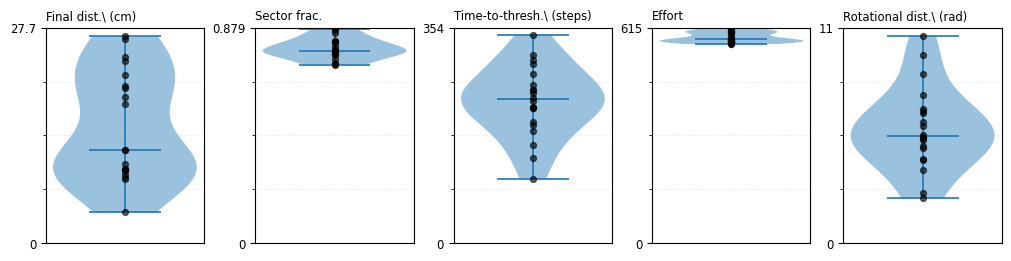

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_robustness_figure(
    per_seed_results, T=CC_T, dist_thresh=CC_DIST_THRESH,
    figsize=(10.0, 2.5),
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.50
FIG_HEIGHT_FRAC = 0.14

configure_pgf()
fig = make_robustness_figure(
    per_seed_results, T=CC_T, dist_thresh=CC_DIST_THRESH,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_robustness.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_robustness.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
import numpy as _np

fd_mean  = agg["final_dist"].mean()
fd_std   = agg["final_dist"].std()
frac_mean = agg["frac_in_sector"].mean()
frac_std  = agg["frac_in_sector"].std()
reach_mean = agg["reached"].mean()
n_trials = CC_N_R * CC_N_THETA

caption = (
    r"Robustness of the optimal open-loop sequential controller across "
    f"{len(SEEDS)} independent Brain seeds "
    f"({n_trials} targets per seed, $T={CC_T}$ steps). "
    r"Left column: per-seed mean distributions for four metrics; "
    r"violin bodies show the kernel-density estimate, dots show individual seeds. "
    r"Right: grand-mean error time series; faint lines show individual-seed "
    r"per-trial means, bold line and shading show grand mean $\pm$ 1\,SD across seeds. "
    r"Top right: distance to target. "
    r"Centre right: shoulder joint error. "
    r"Bottom right: elbow joint error. "
    f"Mean final distance: ${fd_mean:.1f} \\pm {fd_std:.1f}$\\,cm; "
    f"sector fraction: ${frac_mean:.3f} \\pm {frac_std:.3f}$; "
    f"mean reach rate: {reach_mean:.2f}."
)

save_caption(CAPTIONS_PATH / "cartesian_control_robustness.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_robustness.tex
Robustness of the optimal open-loop sequential controller across 20 independent Brain seeds (24 targets per seed, $T=1000$ steps). Left column: per-seed mean distributions for four metrics; violin bodies show the kernel-density estimate, dots show individual seeds. Right: grand-mean error time series; faint lines show individual-seed per-trial means, bold line and shading show grand mean $\pm$ 1\,SD across seeds. Top right: distance to target. Centre right: shoulder joint error. Bottom right: elbow joint error. Mean final distance: $15.0 \pm 6.9$\,cm; sector fraction: $0.793 \pm 0.041$; mean reach rate: 0.89.
